In [6]:
import pandas as pd
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split 
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('PL_GW11.csv')


In [8]:
df.head()
print(df.isnull().sum())

Round                    0
Team                     0
Expected goals (xG)      0
Total shots              0
Big chances              0
Accurate passes          0
Corners                  0
Offsides                 0
Shots                  220
Shots on target          0
Shots off target         0
Blocked shots            0
Shots inside box         0
Shots outside box        0
xG on target (xGOT)      0
xG open play             0
xG set play              0
Own half                 0
Opposition half          0
Passes                   0
Accurate long balls      0
Accurate crosses         0
Throws                   0
Duels won                0
Duels                  220
Interceptions            0
Yellow cards             0
Red cards                0
dtype: int64


In [9]:
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
num_columns = df.select_dtypes(include='number').columns.tolist()


In [10]:
#Normalisasi
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[num_columns])
scaled_df = pd.DataFrame(scaled, columns=num_columns)


C:\Users\lenov\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\_array_api.py:686: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
C:\Users\lenov\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\_array_api.py:706: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [11]:
#Mendefinisikan Kriteria

positive_indicator = ['Possession','Total_shots','Shots_on_target','Expected_goals_(xG)', 'Big_chances','Passes_completed','Duels_won','Clearances']
negative_indicator = ['Fouls', 'Yellow_cards', 'Red_cards']

positive = [c for c in positive_indicator if c in scaled_df]
negative = [c for c in negative_indicator if c in scaled_df]

In [12]:
#Mendefinisikan Team Power
scaled_df['Power'] = scaled_df[positive].sum(axis=1) - scaled_df[negative].sum(axis=1)
df['Power'] = scaled_df['Power']

In [13]:
#Definisi Variabel
X = scaled_df.drop(columns=['Power'])
y = scaled_df['Power']

#Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

#Memprediksi Power semua tim
df['team_power'] = model.predict(X)

In [14]:
print(df.columns)

Index(['Round', 'Team', 'Expected_goals_(xG)', 'Total_shots', 'Big_chances',
       'Accurate_passes', 'Corners', 'Offsides', 'Shots', 'Shots_on_target',
       'Shots_off_target', 'Blocked_shots', 'Shots_inside_box',
       'Shots_outside_box', 'xG_on_target_(xGOT)', 'xG_open_play',
       'xG_set_play', 'Own_half', 'Opposition_half', 'Passes',
       'Accurate_long_balls', 'Accurate_crosses', 'Throws', 'Duels_won',
       'Duels', 'Interceptions', 'Yellow_cards', 'Red_cards', 'Power',
       'team_power'],
      dtype='object')


In [15]:
final_ranks = df.groupby('Team')['team_power'].mean().sort_values(ascending=False)

print("PREDIKSI KLASMEN EPL 25/26")
print(final_ranks)

PREDIKSI KLASMEN EPL 25/26
Team
Arsenal                    1.961205
Manchester City            1.910195
Manchester United          1.861519
Crystal Palace             1.808725
Chelsea                    1.773997
Liverpool                  1.663522
Brentford                  1.538548
Leeds United               1.403280
Everton                    1.368156
Brighton & Hove Albion     1.341455
Nottingham Forest          1.265312
AFC Bournemouth            1.254347
Newcastle United           1.160437
Sunderland                 1.125401
Tottenham Hotspur          1.115448
West Ham United            1.071399
Fulham                     1.070503
Aston Villa                0.971013
Wolverhampton Wanderers    0.918148
Burnley                    0.852589
Name: team_power, dtype: float32


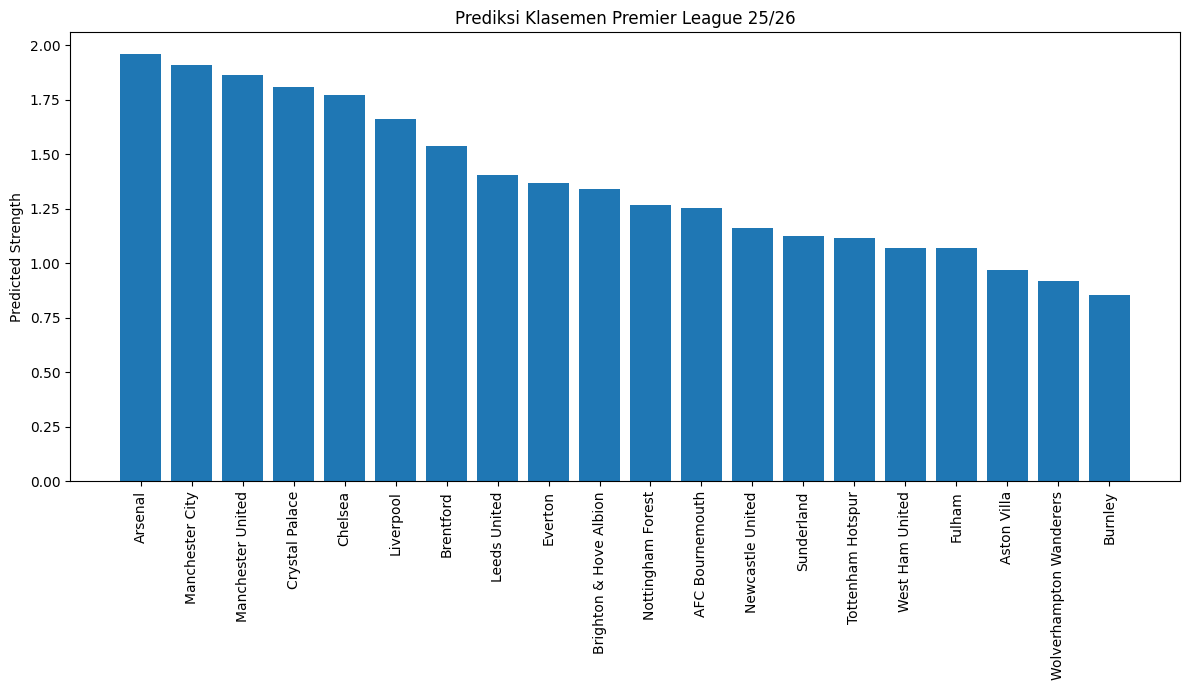

In [16]:
plt.figure(figsize=(12, 7))
plt.bar(final_ranks.index, final_ranks.values)
plt.xticks(rotation=90)
plt.ylabel("Predicted Strength")
plt.title("Prediksi Klasemen Premier League 25/26")
plt.tight_layout()
plt.show()